# BioProtean Lab Workflow for spot detection of smFISH spots

1. Register raw smFISH images.
    Use the merfish3d-analysis package in the Qi2lab GitHub to perform image correction, deconvolution, local and global registration. 
2. Save registered, deconvolved zarr files from the qi2labdatastore as TIFF files.
3. Perform CellPose Segmentation on the registered polyDT channel. Save as TIFF.
4. Import the above data in BigFISH.
5. Perform spot detection in BigFISH.

## Step 5: Spot Detection

Spot detection with BIG FISH can be performed in 2D or 3D

In [1]:
import os
import numpy as np
import bigfish
import bigfish.stack as stack
import bigfish.detection as detection
import bigfish.multistack as multistack
import bigfish.plot as plot
import pandas as pd
import matplotlib.pyplot as plt
from skimage import segmentation
import matplotlib.patches as mpatches
from scipy import ndimage
print("Big-FISH version: {0}".format(bigfish.__version__))

Big-FISH version: 0.6.2


In [2]:
# hard-code the paths of our input and output directories
path_input = "/data/smFISH/20251028_bartelle_smFISH_mm_microglia_newbuffers/qi2labdatastore/big_fish"
path_output = "/data/smFISH/20251028_bartelle_smFISH_mm_microglia_newbuffers/qi2labdatastore/big_fish"

metadata = pd.read_csv("/data/smFISH/20251028_bartelle_smFISH_mm_microglia_newbuffers/scan_metadata.csv")

In [3]:
# Load in data 
path = os.path.join(path_input, "max_projected_tile000round000corrected_polyDT.ome.tiff")
polyDT_mip = stack.read_image(path)
# nuc_mip = stack.maximum_projection(nuc)
print("polyDT channel")
print("\r shape: {0}".format(polyDT_mip.shape))
print("\r dtype: {0}".format(polyDT_mip.dtype), "\n")


# NOTE: When I converted to tiff files, they indexed from 0 so bit 4 is actually bit 5, Itgam
# These tiffs are the registered, deconvolved image

path = os.path.join(path_input, "tile000bit004.ome.tiff")
rna = stack.read_image(path)
print("smfish channel")
print("\r shape: {0}".format(rna.shape))
print("\r dtype: {0}".format(rna.dtype))

polyDT channel
 shape: (2048, 2048)
 dtype: uint16 

smfish channel
 shape: (63, 2048, 2048)
 dtype: uint16


In [15]:
# move this code block or delete it

rna_mip = stack.maximum_projection(rna)
print("smfish channel (2D maximum projection)")
print("\r shape: {0}".format(rna_mip.shape))
print("\r dtype: {0}".format(rna_mip.dtype))

smfish channel (2D maximum projection)
 shape: (2048, 2048)
 dtype: uint16


In [ ]:
# Detect spots in 2D
# Does not use the polyDT fiducial channel
spots, threshold = detection.detect_spots(
    images=rna_mip, 
    return_threshold=True, 
    voxel_size=(103, 103),  # in nanometer (one value per dimension yx)
    spot_radius=(150, 150))  # in nanometer (one value per dimension yx)
print("detected spots")
print("\r shape: {0}".format(spots.shape))
print("\r dtype: {0}".format(spots.dtype))
print("\r threshold: {0}".format(threshold))

detected spots
 shape: (3080, 3)
 dtype: int64
 threshold: 484.0


In [ ]:
spots_post_decomposition, dense_regions, reference_spot = detection.decompose_dense(
image=rna_mip, 
spots=spots, 
voxel_size=(103, 103), 
spot_radius=(150, 150), 
alpha=0.7,  # alpha impacts the number of spots per candidate region
beta=1,  # beta impacts the number of candidate regions to decompose
gamma=5)  # gamma the filtering step to denoise the image
print("detected spots before decomposition")
print("\r shape: {0}".format(spots.shape))
print("\r dtype: {0}".format(spots.dtype), "\n")
print("detected spots after decomposition")
print("\r shape: {0}".format(spots_post_decomposition.shape))
print("\r dtype: {0}".format(spots_post_decomposition.dtype))

NameError: name 'detection' is not defined

In [ ]:
spots_post_clustering, clusters = detection.detect_clusters(
    spots=spots_post_decomposition, 
    voxel_size=(103, 103), 
    radius=350, 
    nb_min_spots=4)
print("detected spots after clustering")
print("\r shape: {0}".format(spots_post_clustering.shape))
print("\r dtype: {0}".format(spots_post_clustering.dtype), "\n")
print("detected clusters")
print("\r shape: {0}".format(clusters.shape))
print("\r dtype: {0}".format(clusters.dtype))

KeyboardInterrupt: 

This is where the issue with the clusters coordinates happens! Something is going on with its coordinates where all the clusters are at the top of the plot. I think it has to do with their slicing.

In [ ]:
# plot
plot.plot_detection(rna_mip, 
                    spots=[spots_post_decomposition, clusters[:, :2]], 
                    shape=["circle", "polygon"], 
                    radius=[3, 6], 
                    color=["red", "blue"],
                    linewidth=[1, 2], 
                    fill=[False, True], 
                    contrast=True)

ValueError: too many values to unpack (expected 2)

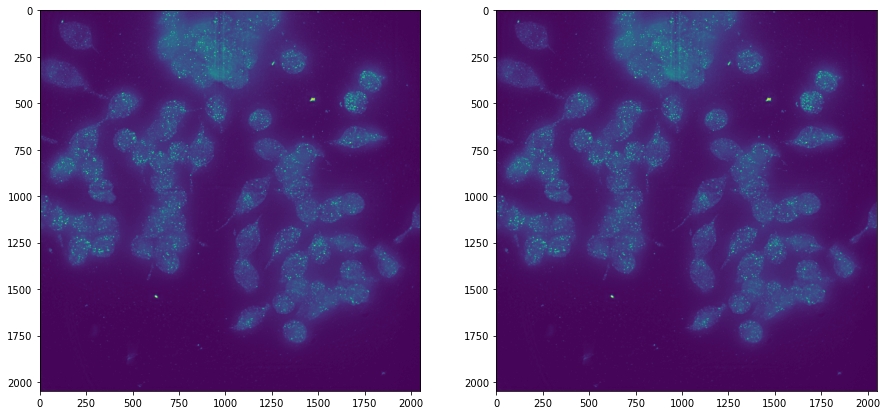

In [16]:
# We plot the MIP but detect in 3D
plot.plot_detection(rna_mip, spots, contrast=True, title="smFISH bit 5 = Itgam | Red = Detected spots")

In [ ]:
# save in npy files
path = os.path.join(path_output, "spots.npy")
stack.save_array(spots_post_clustering, path)
path = os.path.join(path_output, "clusters.npy")
stack.save_array(clusters, path)

# save in csv files
path = os.path.join(path_output, "spots.csv")
stack.save_data_to_csv(spots_post_clustering, path)
path = os.path.join(path_output, "clusters.csv")
stack.save_data_to_csv(clusters, path)

## Step 6: Plot Results

From Notebook 6 - Extract cell level results.ipynb

In [ ]:
# Detection is done in 3D but plotted in 2D
# Here you see we create the plots using the polyDT maxiumum intensity projection


# stretch the contrast otherwise the spots will be dim and hard to see
polyDT_image_contrasted = stack.rescale(polyDT_mip, channel_to_stretch=0)

image_contrasted = stack.rescale(rna, channel_to_stretch=0)
image_contrasted = stack.maximum_projection(image_contrasted)

Read in segmentation and detection results

In [7]:
# segmented cells
path = os.path.join(path_output, "max_projected_tile000round000corrected_polyDT.ome_cp_masks.tif")
cell_label = stack.read_image(path)
print("segmented cells")
print("\r shape: {0}".format(cell_label.shape))
print("\r dtype: {0}".format(cell_label.dtype), "\n")

# detected spots
path = os.path.join(path_output, "spots.csv")
spots = stack.read_array_from_csv(path, dtype=np.int64)
print("detected spots")
print("\r shape: {0}".format(spots.shape))
print("\r dtype: {0}".format(spots.dtype), "\n")

# detected foci
path = os.path.join(path_output, "clusters.csv")
clusters = stack.read_array_from_csv(path, dtype=np.int64)
print("detected clusters")
print("\r shape: {0}".format(clusters.shape))
print("\r dtype: {0}".format(clusters.dtype))

segmented cells
 shape: (2048, 2048)
 dtype: uint16 

detected spots
 shape: (4070, 4)
 dtype: int64 

detected clusters
 shape: (56, 5)
 dtype: int64


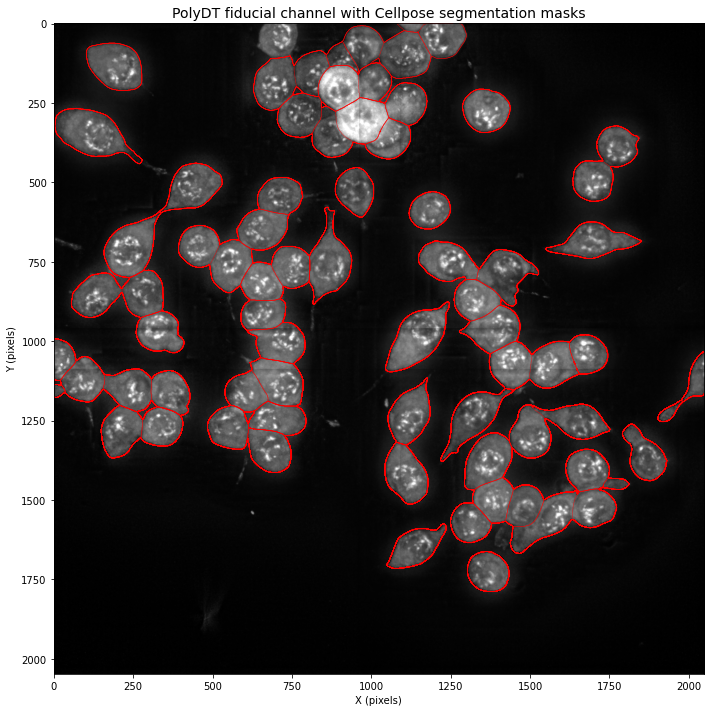

In [8]:
# visuzalize the Cellpose segmentations on top of the polyDT channel

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 10))

# Display the polyDT_mip image
ax.imshow(polyDT_image_contrasted, cmap='gray')

# Overlay the cellpose segmentation masks as outlines using contour
ax.contour(cell_label, levels=np.unique(cell_label)[1:], colors='red', linewidths=0.5, alpha=0.7)

# # Overlay the cellpose segmentation masks as outlines
# # Use find_boundaries to get the edges of the segmentation
# boundaries = segmentation.find_boundaries(cell_label, mode='inner')
# ax.imshow(boundaries, cmap='Reds', alpha=0.5)

ax.set_title('PolyDT fiducial channel with Cellpose segmentation masks', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.show()

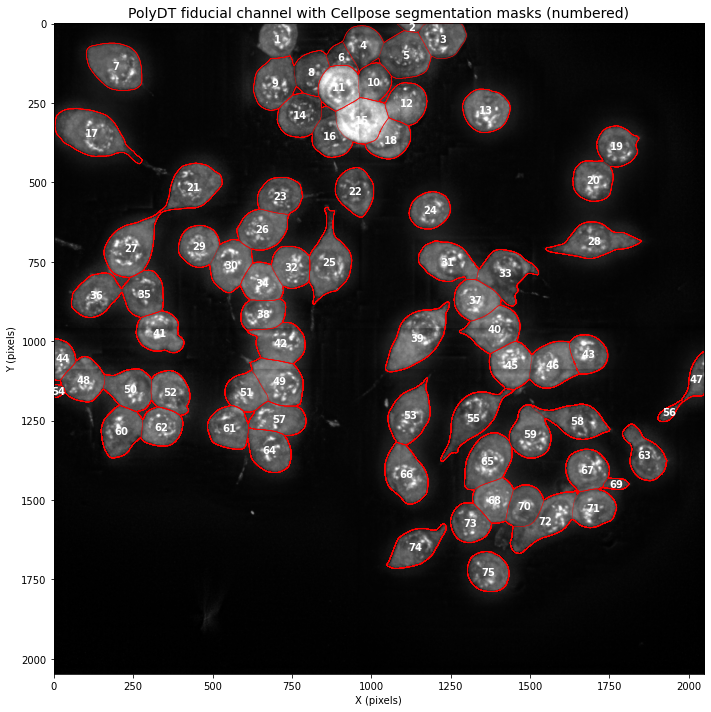

In [9]:
# create the figure with cells numbered

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 10))

# Display the polyDT_mip image
ax.imshow(polyDT_image_contrasted, cmap='gray')

# Overlay the cellpose segmentation masks as outlines using contour
ax.contour(cell_label, levels=np.unique(cell_label)[1:], colors='red', linewidths=0.5, alpha=0.7)

# # Overlay the cellpose segmentation masks as outlines
# # Use find_boundaries to get the edges of the segmentation
# boundaries = segmentation.find_boundaries(cell_label, mode='inner')
# ax.imshow(boundaries, cmap='Reds', alpha=0.5)

# Add cell numbers at the centroid of each cell
cell_ids = np.unique(cell_label)
cell_ids = cell_ids[cell_ids != 0]  # Remove background label (0)

for cell_id in cell_ids:
    # Find centroid of the cell
    cell_mask = cell_label == cell_id
    coords = np.where(cell_mask)
    centroid_y = np.mean(coords[0])
    centroid_x = np.mean(coords[1])
    
    # Add text label at centroid
    ax.text(centroid_x, centroid_y, str(int(cell_id)), 
            color='white', fontsize=10, fontweight='bold',
            ha='center', va='center',
            )

ax.set_title('PolyDT fiducial channel with Cellpose segmentation masks (numbered)', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.show()

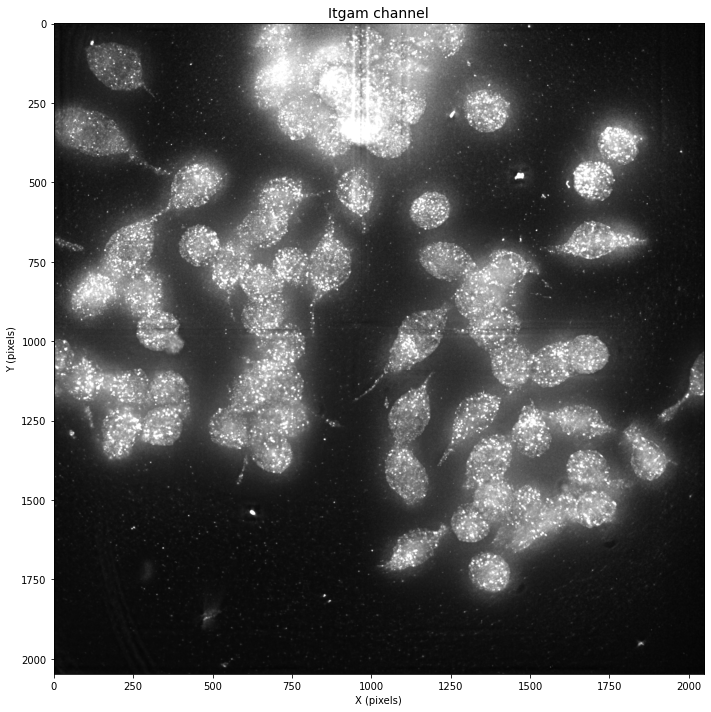

In [10]:
# visuzalize the Cellpose segmentations on top of the Itgam channel

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 10))

# Display the Itgam channel image
ax.imshow(image_contrasted, cmap='gray')

# # Overlay the cellpose segmentation masks as outlines using contour
# ax.contour(cell_label, levels=np.unique(cell_label)[1:], colors='red', linewidths=0.5, alpha=0.7)

# # Overlay the cellpose segmentation masks as outlines
# # Use find_boundaries to get the edges of the segmentation
# boundaries = segmentation.find_boundaries(cell_label, mode='inner')
# ax.imshow(boundaries, cmap='Reds', alpha=0.5)

ax.set_title('Itgam channel', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.show()

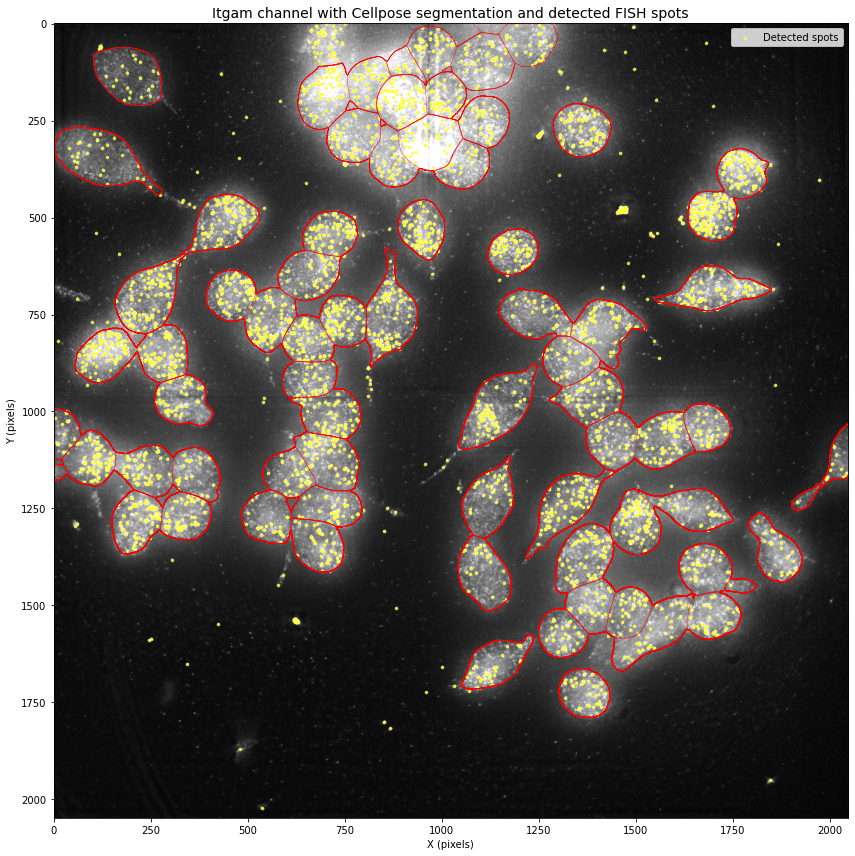

In [11]:
# visualize the RNA channel with Cellpose segmentations and detected FISH spots

# Create figure and axes
fig, ax = plt.subplots(figsize=(14, 12))

# Display the contrast-enhanced Itgam channel image in grayscale
ax.imshow(image_contrasted, cmap='gray')

# Overlay the cellpose segmentation masks as outlines using contour
ax.contour(cell_label, levels=np.unique(cell_label)[1:], colors='red', linewidths=0.5, alpha=0.7)

# Overlay detected FISH spots
# spots has shape (n_spots, 4) with format (z, y, x, intensity)
spot_z = spots[:, 0]
spot_y = spots[:, 1]
spot_x = spots[:, 2]

# Plot detected spots as yellow circles (smaller size)
ax.scatter(spot_x, spot_y, c='yellow', s=10, marker='o', 
           edgecolors='white', linewidth=0.3, alpha=0.8, label='Detected spots')

ax.set_title('Itgam channel with Cellpose segmentation and detected FISH spots', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

Now, add the code to create the dataframe of spots. This is a work in progress